Вам даны данные о 23 479 сигналах с различных набором характеристик этих сигналов. Ваша задача кластеризовать эти сигналы на три кластера по типу сигналов: два кластера отображают типы сигналов (гамма-кванты или нейтроны), третий кластер представляет себя группу сигналов, которые не поддаются кластеризации. (Нумерация кластеров с 0: 0,1,2).



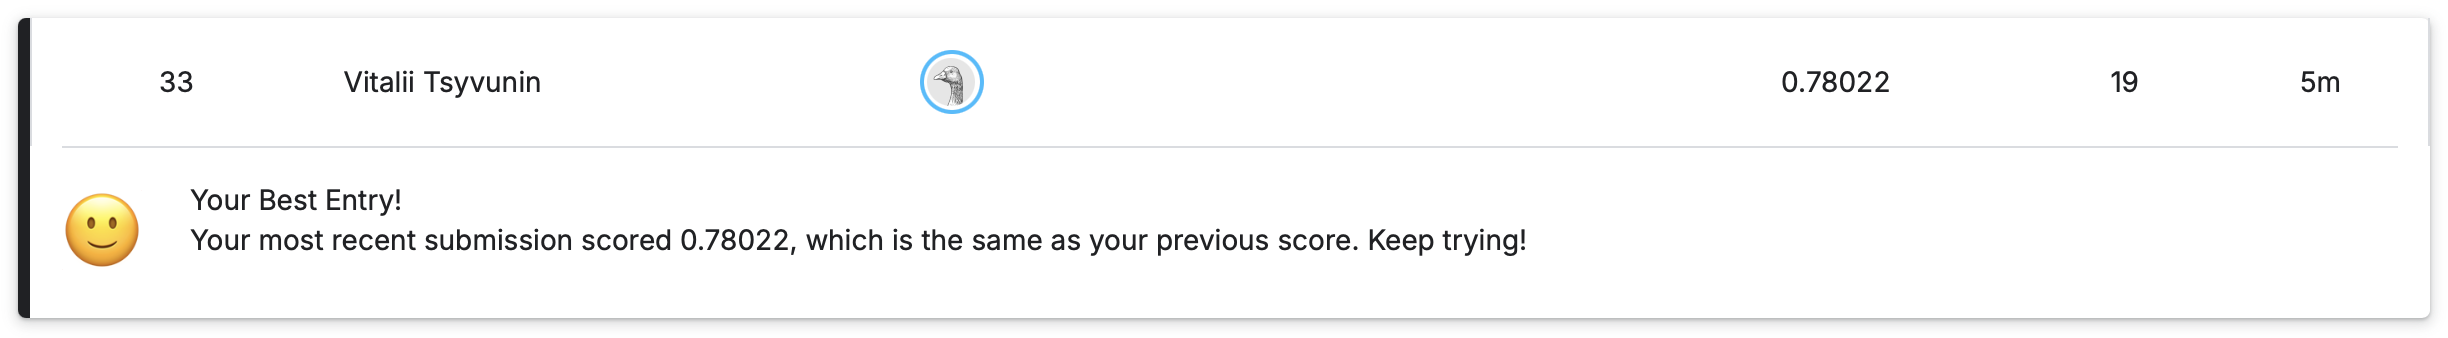

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler

import umap
import hdbscan


In [122]:
import warnings
warnings.filterwarnings("ignore")

In [123]:
pd.set_option('display.max_columns', None)

# Исследование и анализ данных

In [124]:
df = pd.read_csv('data.txt', sep=' ', header=None, skipinitialspace=True)
df = df.drop([0, 1, 2, 3, 504], axis=1) # удаление лишнего

In [125]:
df.shape

(23479, 500)

Text(0, 0.5, 'bit ADC')

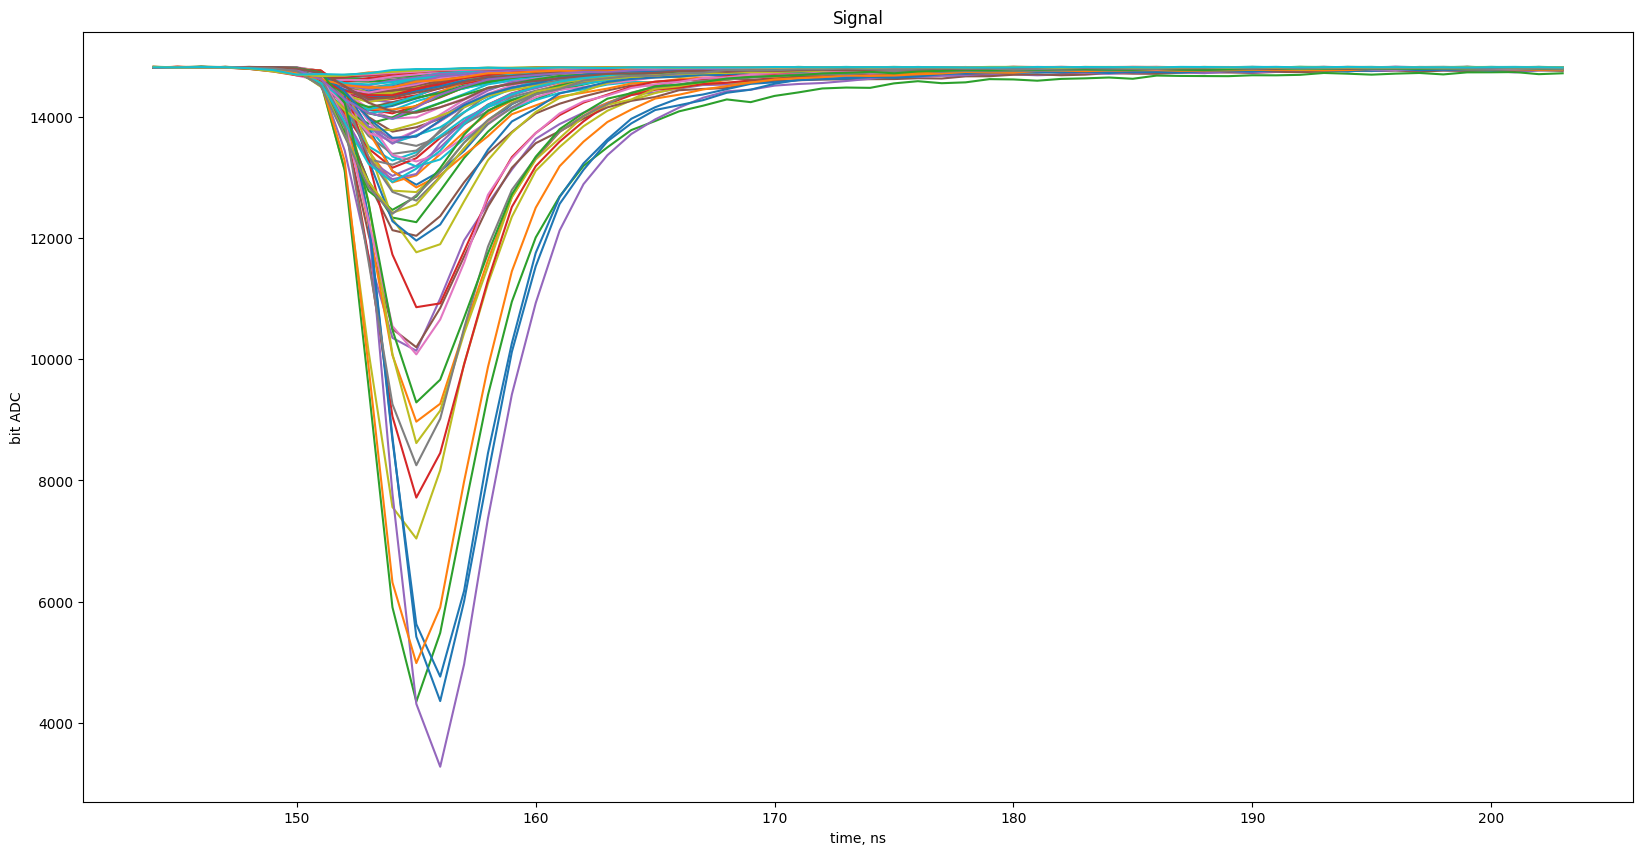

In [126]:
N=range(0,100)
ax = df.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Поиск пропущенных значений

In [127]:
np.isnan(df).sum().sort_values()

4      0
345    0
344    0
343    0
342    0
      ..
163    0
162    0
161    0
174    0
503    0
Length: 500, dtype: int64

In [128]:
X = df.values.astype(np.float64)

Изучим данные по графикам

Найдем медианнные значения всех сигналов

Text(0.5, 1.0, 'Медиана')

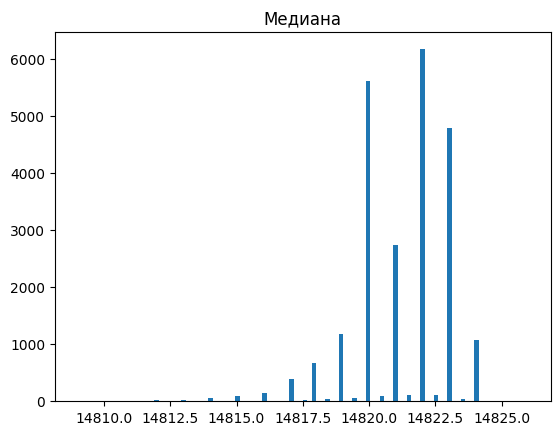

In [129]:
baselines = np.median(X, axis=1)
plt.hist(baselines, bins=100)
plt.title('Медиана')

Есть разброс

В основном от 14820 до 14823

Text(0.5, 1.0, 'Позиция пика')

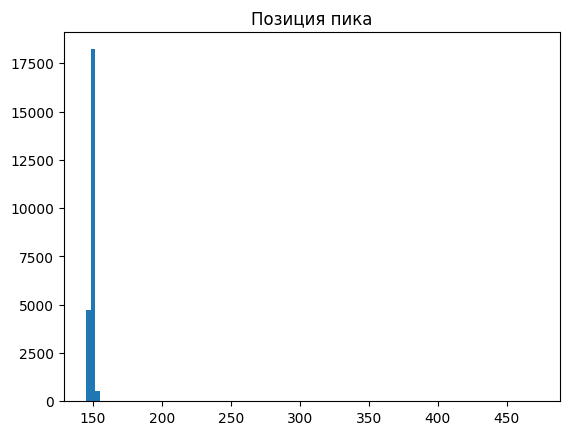

In [130]:
peaks = np.argmin(X, axis=1)
plt.hist(peaks, bins=100)
plt.title(f'Позиция пика')

# Предобработка данных

Как в статье: возьмем первые 50 значений сигналов до пика

Возьмем среднеее значение и вычтим из него все значения сигналов

In [131]:
baseline = X[:, :50].mean(axis=1, keepdims=True)
noise_std = X[:, :50].std(axis=1)

X = baseline - X      

print(f"Средний шум: {noise_std.mean():.1f}")
print(f"Средняя амплитуда пика = {X.max(axis=1).mean():.1f}")

Средний шум: 2.7
Средняя амплитуда пика = 1835.1


# Извлечение признаков

In [132]:
n = len(X)
amplitude = np.zeros(n)
volume    = np.zeros(n)
tau       = np.zeros(n)
psd       = np.zeros(n)
valid     = np.ones(n, dtype=bool)   

psd_short_len=8

for i in range(n):
    p   = X[i]
    p_max_pos  = np.argmax(p)
    amp = p[p_max_pos]
    amplitude[i] = amp

    # отбраковываем сразу слишком слабые сигналы
    if amp < 5 * noise_std[i]:
        valid[i] = False
        continue

    # конец сигнала: где амплитуда упала до 3σ от нуля
    tail = p[p_max_pos:]
    if (tail < 3 * noise_std[i]).any():
        end_rel = np.argmax(tail < 3 * noise_std[i])
    else:
        end_rel = len(tail) - 1
    end_abs = p_max_pos + end_rel
    signal = p[p_max_pos:end_abs + 1]

    volume[i] = signal.sum() # по сути площадь под сигналов

    # находим PSD
    long_gate  = p[p_max_pos: end_abs + 1].sum()
    short_gate = p[p_max_pos: p_max_pos + psd_short_len].sum()
    if long_gate > 0:
        psd[i] = (long_gate - short_gate) / long_gate
    else:
        valid[i] = False
        continue

    # находим время затухания
    thr = 0.2 * amp
    below = np.where(signal < thr)[0]
    if len(below) < 5:
        tau[i] = np.nan
        continue
    fit_start = below[0]
    y = signal[fit_start:]
    x = np.arange(len(y))
    try:
        mask = y > 0
        if mask.sum() < 5:
            tau[i] = np.nan
            continue
        coef = np.polyfit(x[mask], np.log(y[mask]), 1) # аппроксимация логарифма амплитуды прямой линией
        slope = coef[0]
        if slope < 0:
            tau[i] = -1.0 / slope
        else:
            tau[i] = np.nan
    except Exception:
        tau[i] = np.nan


# Кластеризация

Берем два основных признака: амплитуда и энергию сигнала

Используем PCA (из статьи)

In [140]:
labels_pca = np.full(len(volume), 2, dtype=int)

Xv = np.column_stack([volume[valid], amplitude[valid]])

pca = PCA(n_components=2).fit(Xv)
labels_pca[valid] = (pca.transform(Xv)[:, 1] > 0).astype(int) # [:, 1] - проекция на вторую компоненту 

In [141]:
lv = labels_pca[valid]
ch  = calinski_harabasz_score(Xv, lv)
sil = silhouette_score(Xv, lv)
print(f"Calinski-Harabasz: {ch:.2f}")
print(f"Silhouette:{sil:.4f}")

Calinski-Harabasz: 258.13
Silhouette:0.0486


Значения как и в статье

Silhouette показывает маленькое значение: слабое качество

## Визуализация

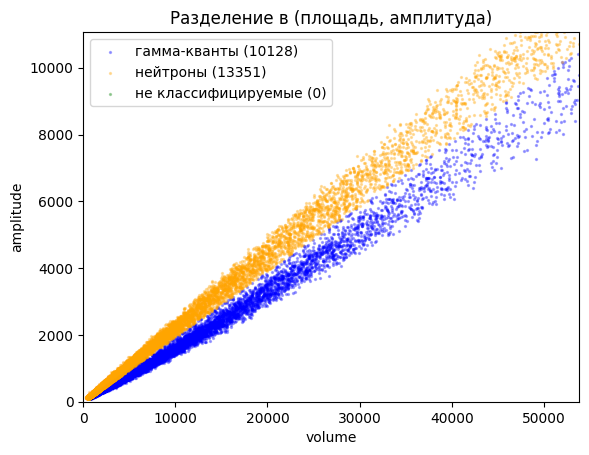

In [142]:
colors = np.array(['blue', 'orange', 'green'])
names  = ['гамма-кванты', 'нейтроны', 'не классифицируемые']

for k in (0, 1, 2):
    m = labels_pca == k
    plt.scatter(volume[m], amplitude[m],
                        s=2, alpha=0.3, c=colors[k], label=f'{names[k]} ({m.sum()})')
plt.xlim(0, np.percentile(volume, 99))
plt.ylim(0, np.percentile(amplitude, 99))
plt.xlabel('volume')
plt.ylabel('amplitude')
plt.title('Разделение в (площадь, амплитуда)')
plt.legend()

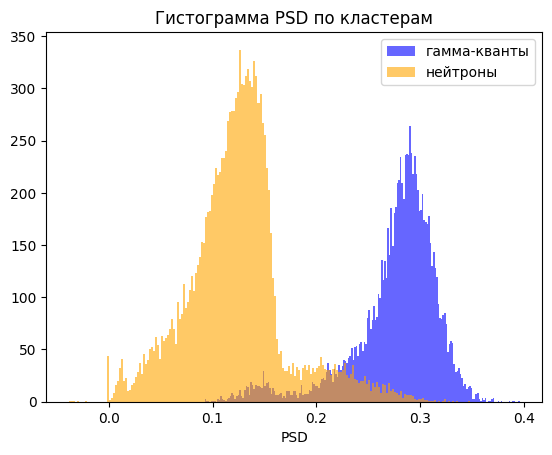

In [143]:
for k in (0, 1):
    m = (labels_pca == k) & valid
    plt.hist(psd[m], bins=200, alpha=0.6, color=colors[k], label=names[k])
plt.xlabel('PSD')
plt.title('Гистограмма PSD по кластерам')
plt.legend()

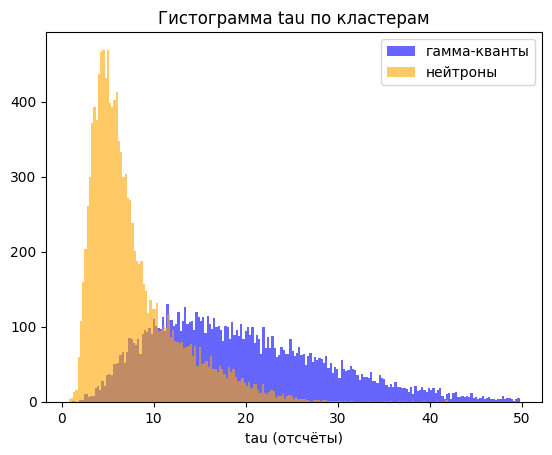

In [144]:
for k in (0, 1):
    m = (labels_pca == k) & valid & np.isfinite(tau)
    tau_k = tau[m]
    tau_k = tau_k[(tau_k > 0) & (tau_k < 50)]
    plt.hist(tau_k, bins=200, alpha=0.6, color=colors[k], label=names[k])
plt.xlabel('tau (отсчёты)')
plt.title('Гистограмма tau по кластерам')
plt.legend()

# Иные способы кластеризации

В качестве основных фичей возьмем аплитуду, энергию, время затухания и psd

## HDBSCAN

In [ ]:
labels_hdbscan = np.full(len(volume), 2, dtype=int)

valid_umap = valid & ~(np.isnan(tau) | np.isnan(psd))
Xv = np.column_stack([volume[valid_umap], amplitude[valid_umap], tau[valid_umap], psd[valid_umap]])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(Xv)

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_scaled)

clusterer = hdbscan.HDBSCAN(min_cluster_size=1000, gen_min_span_tree=True)
labels = clusterer.fit_predict(embedding)

In [162]:
labels_hdbscan[valid_umap] = labels.astype(int)

In [165]:
labels_hdbscan[labels_hdbscan == -1] = 2

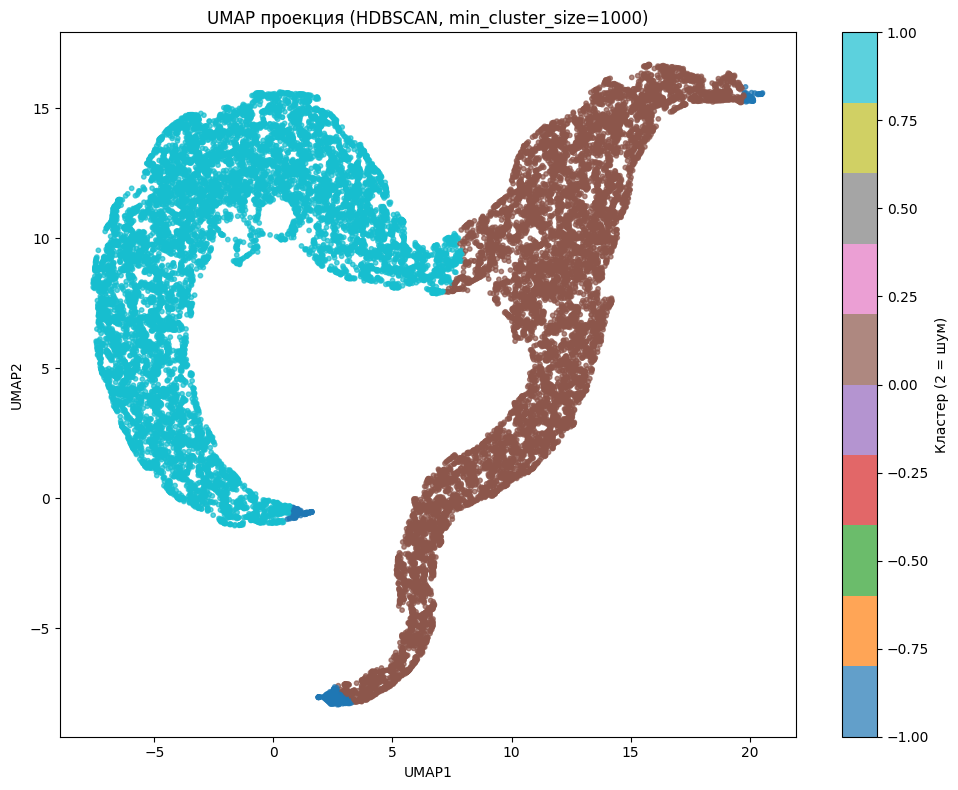

In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embedding[:,0], embedding[:,1], c=labels_hdbscan[valid_umap], cmap='tab10', s=10, alpha=0.7)
plt.colorbar(scatter, label='Кластер (2 = шум)')
plt.title(f'UMAP проекция (HDBSCAN)')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.tight_layout()
plt.show()

График получился неоднородный. 2 области очень сильно пересекаются

## Иерархическая

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=2)
labels = agg.fit_predict(Xv)


In [220]:
np.unique_counts(labels)

UniqueCountsResult(values=array([0, 1]), counts=array([19597,  3122]))

На двух кластерах показывает сильный перевес

## K-Means

In [ ]:
from sklearn.cluster import KMeans

labels_kmeans = np.full(len(volume), 2, dtype=int)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(Xv)

distances = np.min(kmeans.transform(Xv), axis=1)
thresh = np.percentile(distances, 95)
noise = distances > thresh
labels[noise] = 2   # третий кластер – шум

labels_kmeans = labels

In [186]:
np.unique_counts(labels_kmeans)

UniqueCountsResult(values=array([0, 1, 2], dtype=int32), counts=array([17755,  3828,  1136]))

Аналогичная ситуация как и с иерархисеской

# Вывод

Лучше всего себя показад метод главных компонент

Остальные способы не могут подстроиться под характрестики сигналов

In [ ]:
result = pd.DataFrame({
    'index': np.arange(len(labels_pca)),
    'cluster': labels_pca,
})
result.to_csv('submission.csv', index=False)